In [16]:
# model
import torch
import torch.nn as nn
import math

class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=256):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len).unsqueeze(1)
        div_term = torch.exp(
            torch.arange(0, d_model, 2) * (-math.log(10000.0) / d_model)
        )
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer("pe", pe.unsqueeze(0))

    def forward(self, x):
        return x + self.pe[:, :x.size(1)]

class DecoderOnlyTransformer(nn.Module):
    def __init__(self, vocab_size, d_model=256, nhead=8, num_layers=6,
                 max_len=256, d_ff=1024, dropout=0.1):
        super().__init__()
        self.token_embedding = nn.Embedding(vocab_size, d_model)
        self.pos_encoding = PositionalEncoding(d_model, max_len)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=d_ff,
            dropout=dropout,
            batch_first=True,
            activation='gelu'
        )
        self.transformer = nn.TransformerEncoder(
            encoder_layer,
            num_layers=num_layers
        )
        self.lm_head = nn.Linear(d_model, vocab_size)

    def generate_square_subsequent_mask(self, size, device):
        mask = torch.triu(torch.ones(size, size, device=device), diagonal=1)
        mask = mask.masked_fill(mask == 1, float("-inf"))
        return mask

    def forward(self, x):
        """
        x: (B, T)
        returns: (B, T, vocab_size)
        """
        B, T = x.size()
        mask = self.generate_square_subsequent_mask(T, x.device)
        x = self.token_embedding(x)
        x = self.pos_encoding(x)
        x = self.transformer(x, mask=mask)
        logits = self.lm_head(x)  # (B, T, vocab_size)
        return logits

def init_weights(m):
    if isinstance(m, nn.Linear):
        torch.nn.init.normal_(m.weight, std=0.02)
        if m.bias is not None:
            torch.nn.init.zeros_(m.bias)

In [17]:
# train
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import numpy as np
import pickle
import math
import time
import os
from datetime import timedelta

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

BATCH_SIZE = 64
GRAD_ACCUM_STEPS = 4
SEQ_LENGTH = 256
MAX_ITERS = 100000
WARMUP_STEPS = 2000

EVAL_EVERY = 1000
LOG_EVERY = 200
EARLY_STOP_PATIENCE = 5


train_data = np.load("train.npy")
val_data = np.load("val.npy")

train_data = np.concatenate(train_data)
val_data = np.concatenate(val_data)

with open("char_to_idx.pkl", "rb") as f:
    char_to_idx = pickle.load(f)
with open("idx_to_char.pkl", "rb") as f:
    idx_to_char = pickle.load(f)

vocab_size = len(char_to_idx)
print(f"Vocab size: {vocab_size} | Train tokens: {len(train_data):,} | Val tokens: {len(val_data):,}")
print(f"Training on device: {DEVICE}\n")

model = DecoderOnlyTransformer(
    vocab_size=vocab_size,
    d_model=256,
    nhead=8,
    num_layers=6,
    max_len=256,
    dropout=0.1
).to(DEVICE)

Vocab size: 65 | Train tokens: 1,108,736 | Val tokens: 138,496
Training on device: cpu



In [18]:
import torch
import torch.nn.functional as F
import pickle
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
import math
device = 'cuda' if torch.cuda.is_available() else 'cpu'

In [19]:
# Load model
model.load_state_dict(torch.load("final_model.pth", map_location=DEVICE))
model.eval()


DecoderOnlyTransformer(
  (token_embedding): Embedding(65, 256)
  (pos_encoding): PositionalEncoding()
  (transformer): TransformerEncoder(
    (layers): ModuleList(
      (0-5): 6 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=256, out_features=256, bias=True)
        )
        (linear1): Linear(in_features=256, out_features=1024, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=1024, out_features=256, bias=True)
        (norm1): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.1, inplace=False)
        (dropout2): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (lm_head): Linear(in_features=256, out_features=65, bias=True)
)

In [20]:
# Load vocab
with open('idx_to_char.pkl', 'rb') as f:
    itos = pickle.load(f)
with open('char_to_idx.pkl', 'rb') as f:
    stoi = pickle.load(f)
with open('chars.pkl', 'rb') as f:
    chars = pickle.load(f)

In [21]:
def encode(s): return [stoi[c] for c in s]
def decode(l): return ''.join([itos[i] for i in l])

In [22]:
def entropy(probs):
    return -torch.sum(probs * torch.log(probs + 1e-9)).item()

In [23]:
context_length = 256

def generate(prompt, max_new_tokens, strategy):
    idx = torch.tensor(encode(prompt), dtype=torch.long, device=device)[None, :]

    for _ in range(max_new_tokens):

        idx_cond = idx[:, -context_length:]  # 🔥 FIX

        logits = model(idx_cond)[:, -1, :]
        probs = F.softmax(logits, dim=-1)

        if strategy == 'greedy':
            next_token = torch.argmax(probs, dim=-1, keepdim=True)

        elif strategy == 'temperature':
            temp = 0.8
            probs_t = F.softmax(logits / temp, dim=-1)
            next_token = torch.multinomial(probs_t, 1)

        elif strategy == 'top_k':
            k = 20
            v, ix = torch.topk(probs, k)
            probs_k = v / v.sum(dim=-1, keepdim=True)  # 🔥 FIX (batch-safe)
            next_token = ix.gather(-1, torch.multinomial(probs_k, 1))

        elif strategy == 'top_p':
            sorted_probs, sorted_idx = torch.sort(probs, descending=True)
            cumulative = torch.cumsum(sorted_probs, dim=-1)

            mask = cumulative > 0.9
            mask[..., 0] = False  # 🔥 FIX (не зануляем всё)

            sorted_probs[mask] = 0
            sorted_probs = sorted_probs / sorted_probs.sum(dim=-1, keepdim=True)

            next_token = sorted_idx.gather(-1, torch.multinomial(sorted_probs, 1))

        elif strategy == 'adaptive':
            ent = entropy(probs)

            if ent < 2.5:
                next_token = torch.argmax(probs, dim=-1, keepdim=True)

            elif ent < 3.5:
                v, ix = torch.topk(probs, 10)
                probs_k = v / v.sum(dim=-1, keepdim=True)
                next_token = ix.gather(-1, torch.multinomial(probs_k, 1))

            else:
                probs_t = F.softmax(logits / 1.2, dim=-1)
                next_token = torch.multinomial(probs_t, 1)

        else:
            raise ValueError()

        idx = torch.cat([idx, next_token], dim=1)

    return decode(idx[0].tolist())

In [24]:
context_length = 256

def beam_search(prompt, max_new_tokens, beam_width=3):
    sequences = [(encode(prompt), 0.0)]

    for _ in range(max_new_tokens):
        all_candidates = []

        for seq, score in sequences:

            # 🔥 FIX: обрезаем контекст
            idx = torch.tensor(seq[-context_length:], device=device)[None, :]

            with torch.no_grad():  # 🔥 ускорение
                logits = model(idx)[:, -1, :]
                probs = F.softmax(logits, dim=-1)

            topk_probs, topk_idx = torch.topk(probs, beam_width)

            for i in range(beam_width):
                token = topk_idx[0, i].item()
                prob = topk_probs[0, i].item()

                candidate = seq + [token]

                # 🔥 защита от log(0)
                candidate_score = score - math.log(prob + 1e-9)

                all_candidates.append((candidate, candidate_score))

        # сортируем по score (меньше = лучше)
        sequences = sorted(all_candidates, key=lambda x: x[1])[:beam_width]

    return decode(sequences[0][0])

In [25]:
def ttr(text):
    tokens = list(text)
    return len(set(tokens)) / len(tokens)

def cer(text):
    repeats = sum(1 for i in range(1, len(text)) if text[i] == text[i-1])
    return repeats / len(text)

In [26]:
strategies = ['greedy', 'temperature', 'top_k', 'top_p', 'adaptive']
prompt = "First Citizen: Before we proceed any further, hear me speak."

results = {}

for strat in strategies:
    texts = [generate(prompt, 200, strat) for _ in range(5)]
    ttrs = [ttr(t) for t in texts]
    cers = [cer(t) for t in texts]

    results[strat] = {
        'TTR': np.mean(ttrs),
        'CER': np.mean(cers)
    }

# Beam separately
texts = [beam_search(prompt, 200) for _ in range(3)]
results['beam'] = {
    'TTR': np.mean([ttr(t) for t in texts]),
    'CER': np.mean([cer(t) for t in texts])
}

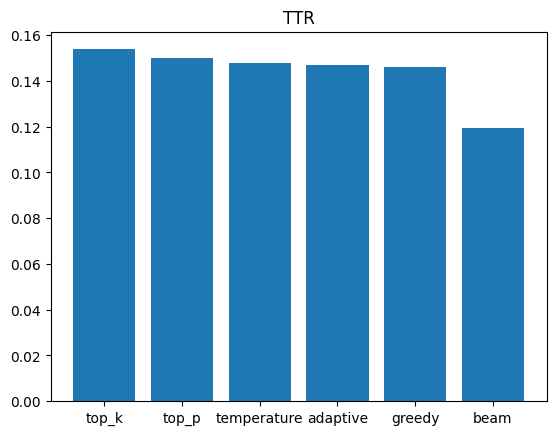

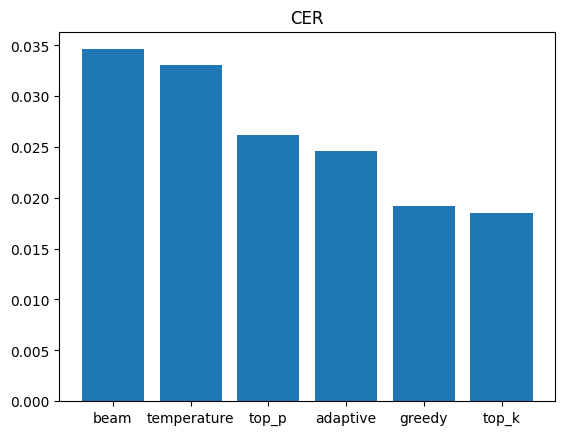

In [27]:
def plot_metric(metric):
    items = sorted(results.items(), key=lambda x: x[1][metric], reverse=True)

    names = [k for k, _ in items]
    values = [v[metric] for _, v in items]

    plt.figure()
    plt.bar(names, values)
    plt.title(metric)
    plt.show()

plot_metric('TTR')
plot_metric('CER')